In [10]:
import sys
#sys.path.insert(1, "../")
#from b_chromatic_utils import get_m_degree #we need the index m-degree
import pulp as pl
import networkx as nx

## Random $d$-regular graph

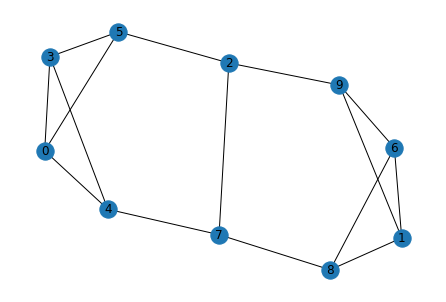

In [31]:
G = nx.random_regular_graph(d=3,n=10)
nx.draw(G, with_labels=True)

## Index m-degree computation.

Take into account that $\mathbf{d}(u,v)=d(u)+d(v)-2$

In [32]:
def get_index_m_degree(G):
    X = [0 for _ in range(0, len(G.edges())+1)]
    Z = [0 for _ in range(0, len(G.edges())+1)]
    max_j = 0
    for u,v in G.edges(): X[G.degree(u)+G.degree(v)-2] += 1
    for j in range(len(G.edges())-1, 0, -1): Z[j] = Z[j+1] + X[j]
    for j in range(1, len(G.nodes)):
        if Z[j-1] >= j:
            max_j = j
    return max_j

## Model definition

In [33]:
b_chr_index_model = pl.LpProblem(name="b-chromatic-index-model")
n = len(G.nodes) #number of vertices
V = list(G.nodes)
E = list(G.edges)
c =  get_index_m_degree(G)#number of colours
C = range(c)

## Variables

In [34]:
w_vars = {j:pl.LpVariable(
                            cat=pl.LpBinary,
                            name="w_{0}".format(j)) 
                            for j in C}
x_vars = {(u,v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="x_{0}_{1}_{2}".format(u,v,c))
                            for u,v in E for c in C}

z_vars = {(u,v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="z_{0}_{1}_{2}".format(u,v,c))
                            for v in E for c in C}

## Constraints

$\sum_{j=1}^c x_{ej}=1$ for every $e\in\{1,\dots, m\}$

In [35]:
one_colour_constraint = {(u,v):b_chr_index_model.addConstraint(
                            pl.LpConstraint(
                                e=pl.lpSum(x_vars[u,v,c] for c in C),
                                sense=pl.LpConstraintEQ,
                                rhs=1,
                                name="one_colour_{0}_{1}".format(u,v))
                        ) for u,v in E}

$x_{ej}+x_{fj}\leq 1$ for every pair of edges $e,f$$ such that $e\cap f\neq \emptyset$

In [39]:
C

range(0, 5)

In [40]:
diff_colour_per_adj_edges_constraint = {(u1,v1,c,u2,v2,c):b_chr_index_model.addConstraint(
                                                            pl.LpConstraint(
                                                                e=x_vars[u1,v1,c] + x_vars[u2,v2,c],
                                                                sense=pl.LpConstraintLE,
                                                                rhs=1,
                                                                name="diff_colour_{0}_{1}_{2}_{3}_{4}_{5}".format(u1,v1,c,u2,v2,c))
                                                            )
                                                        for i, (u1,v1) in enumerate(E) for u2,v2 in E[i+1:] 
                                                        for c in C
                                                        if u1 == u2 or u1 == v2 or v1 == u2 or v1 == v2}

In [27]:
for i, (u1,v1) in enumerate(E):
    for u2,v2 in E[i+1:]:
        if u1 == u2 or u1 == v2 or v1 == u2 or v1 == v2:
            print({u1,v1}, {u2,v2})

{0, 1} {0, 3}
{0, 1} {0, 2}
{0, 1} {1, 2}
{0, 1} {1, 3}
{0, 3} {0, 2}
{0, 3} {1, 3}
{0, 3} {2, 3}
{0, 2} {1, 2}
{0, 2} {2, 3}
{1, 2} {1, 3}
{1, 2} {2, 3}
{1, 3} {2, 3}
